# Preambolo

In [ ]:
import numpy as np
import matplotlib as mtp
import scipy as sp
import matplotlib.pyplot as plt
import pandas as pd
import math
import sys
from scipy.stats import norm
from scipy.stats import chi2
from matplotlib.ticker import FormatStrFormatter
from scipy import stats
from scipy.constants import g
from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import StrMethodFormatter
!pip install uncertainties
from uncertainties import ufloat
from uncertainties import unumpy as unp
from uncertainties.umath import sqrt
from uncertainties import ufloat
from scipy.constants import epsilon_0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 2.1 MB/s eta 0:00:00


In [ ]:
import os
import sys
import shutil

%cd /content/
if os.path.exists('/content/Esperienze-in-laboratorio'):
    shutil.rmtree('/content/Esperienze-in-laboratorio')

!git clone https://github.com/matteodeclich/Esperienze-in-laboratorio.git

percorso_libreria = '/content/Esperienze-in-laboratorio/Libreria_python'
if percorso_libreria not in sys.path:
    sys.path.insert(0, percorso_libreria)

try:
    from analisi_dati import *
    print("✅ Tutto pronto! Librerie installate e modulo importato.")
except Exception as e:
    print(f"❌ Errore durante l'import: {e}")

%cd Esperienze-in-laboratorio

/content
Cloning into 'Esperienze-in-laboratorio'...
remote: Enumerating objects: 1092, done.
remote: Counting objects: 100% (160/160), done.
remote: Compressing objects: 100% (85/85), done.
remote: Total 1092 (delta 107), reused 125 (delta 75), pack-reused 932 (from 2)
Receiving objects: 100% (1092/1092), 18.40 MiB | 42.62 MiB/s, done.
Resolving deltas: 100% (573/573), done.
✅ Tutto pronto! Librerie installate e modulo importato.
/content/Esperienze-in-laboratorio


#Pull

In [ ]:
!git pull

Already up to date.


# Misure statiche


In [ ]:
df=pd.read_excel("Legge di Hooke.xlsx", sheet_name=0)
df=df.fillna('')
df.round(5)

,m[kg],x [m],l [m],σl [m],x0 [m]
0,0.05,1.24,0.02,0.01414,1.26
1,0.10,1.23,0.03,0.01414,σx0 [m]
2,0.20,1.20,0.06,0.01414,0.01
3,0.30,1.16,0.10,0.01414,
4,0.40,1.13,0.13,0.01414,
5,0.50,1.10,0.16,0.01414,
6,0.60,1.07,0.19,0.01414,
7,0.70,1.04,0.22,0.01414,
8,0.80,1.01,0.25,0.01414,
9,0.90,0.97,0.29,0.01414,


Il risultato del fit y = k0·x è:
  k0 = 0.31796670±0.00837341


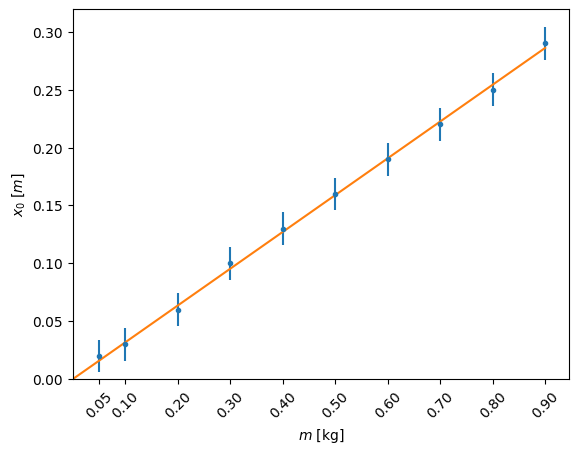

Il risultato del test del χ² è:
  χ²               = 0.52103418
  Gradi di libertà = 9
  χ² ridotto       = 0.057892687
  Il p-value associato è: 0.99996368
La misura statica di k è: 30.85±0.81


In [ ]:
d_l0 = pd.to_numeric(df.iloc[:, 2], errors='coerce').dropna().values
d_sl0 = pd.to_numeric(df.iloc[:, 3] , errors='coerce').dropna().values
l0 = unp.uarray(d_l0, d_sl0)

m0 = pd.to_numeric(df.iloc[:, 0], errors='coerce').dropna().values

g = ufloat(9.81, 0.01)

k0 = minquadw_kx(m0, unp.nominal_values(l0), unp.std_devs(l0), "k0" )

def retta(x, k):
    return k * x
t = np.linspace(0, max(m0), 100)

plt.errorbar(m0, unp.nominal_values(l0), yerr=unp.std_devs(l0), fmt='o', ls='none', label='Dati', ms=3)
plt.plot(t, retta(t, unp.nominal_values(k0)))

plt.xlim(left=0)
plt.ylim(bottom=0)
plt.xticks(rotation=45)
plt.xticks(unp.nominal_values(m0))
plt.xlabel(r'$m$ [kg]')
plt.ylabel(r'$x_0$ [$m$]')
plt.show()

print("="*70)
chi_quadro(unp.nominal_values(l0), m0*k0, unp.std_devs(l0), 1);
print("="*70)
k_el0 = g/k0
print(f"La misura statica di k è: {k_el0:.4P}")
print("="*70)

# Misure dinamiche


In [ ]:
df1=pd.read_excel("Legge di Hooke.xlsx", sheet_name=1)
df1=df1.fillna('')
df1.round(5)

,Masse (kg),0.05,0.15,0.25,0.35,0.45,0.55,Masse corrette [kg]
0,1,23.84400,14.49000,11.28500,9.62300,8.3830,7.69100,0.053767
1,2,24.54300,14.62200,11.17700,9.57300,8.4060,7.59100,0.153767
2,3,24.13000,14.65300,11.30100,9.61600,8.3880,7.65900,0.253767
3,4,24.36000,14.53400,11.29900,9.63000,8.3860,7.60000,0.353767
4,5,24.42500,14.54200,11.26000,9.61700,8.4020,7.63200,0.453767
5,ω,24.26040,14.56820,11.26440,9.61180,8.3930,7.63460,0.553767
6,σω,0.27716,0.06719,0.05152,0.02240,0.0103,0.04148,Massa molla [kg]
7,σω_,0.12395,0.03005,0.02304,0.01002,0.0046,0.01855,0.0113


Il risultato del fit y = k1·x è:
  k1 = 1.2278185±0.0011065


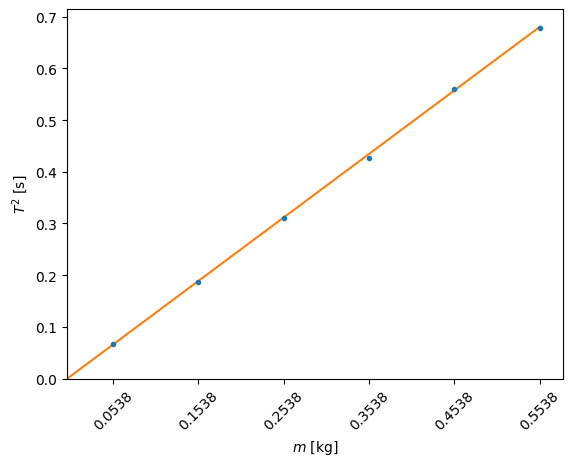

Il risultato del test del χ² è:
  χ²               = 107.50835
  Gradi di libertà = 5
  χ² ridotto       = 21.50167
  Il p-value associato è: 1.3769e-21


In [ ]:
omega_m =unp.uarray(df1.iloc[5, 1:7], df1.iloc[7, 1:7 ])
T=2*np.pi/omega_m
T_2=T**2
masse = df1.iloc[0:6, 7]
m1 = pd.to_numeric(masse, errors='coerce').dropna().values

k1 = minquadw_kx(m1, unp.nominal_values(T_2), unp.std_devs(T_2), "k1")
t = np.linspace(0, max(m1))

plt.errorbar(m1, unp.nominal_values(T_2), yerr=unp.std_devs(T_2), fmt='o', ls='none', label='Dati', ms=3)
plt.plot(t, retta(t, k1.nominal_value))

plt.xlim(left=0)
plt.ylim(bottom=0)
plt.xticks(rotation=45)
plt.xticks(m1)
plt.xlabel(r'$m$ [kg]')
plt.ylabel(r'$T^2$ [s]')
plt.show()

print("="*70)
chi_quadro(T_2, k1*m1, unp.std_devs(T_2), 1);
print("="*70)

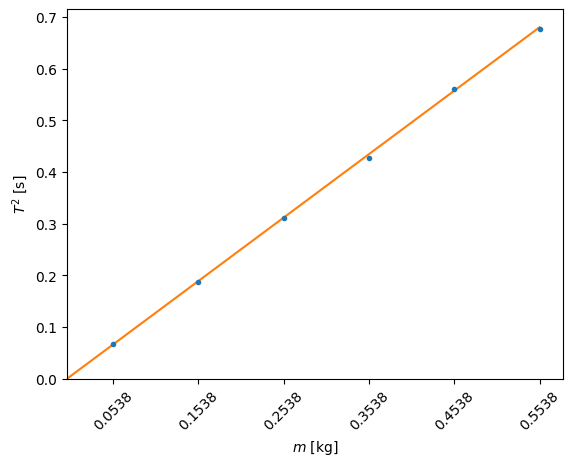

Il risultato del test del χ² è:
  χ²               = 5
  Gradi di libertà = 5
  χ² ridotto       = 1
  Il p-value associato è: 0.41588019
La misura dinamica di k è: 32.15±0.03
Test di compatibilità tra k_statico e k_dinamico: |t| = 1.59909


In [ ]:
sy_posteriori= np.sqrt(np.sum((unp.nominal_values(T_2) - k1.nominal_value*m1)**2) / (len(T_2) - 1) )

plt.errorbar(m1, unp.nominal_values(T_2), yerr=sy_posteriori, fmt='o', ls='none', label='Dati', ms=3)
plt.plot(t, retta(t, k1.nominal_value))

plt.xlim(left=0)
plt.ylim(bottom=0)
plt.xticks(rotation=45)
plt.xticks(m1)
plt.xlabel(r'$m$ [kg]')
plt.ylabel(r'$T^2$ [s]')
plt.show()

print("="*70)
sy_array = np.full(len(T_2), sy_posteriori)
chi_quadro(T_2, k1 * m1, sy_array, 1)
print("="*70)
k_el1=(4*np.pi**2)/k1
print(f"La misura dinamica di k è: {k_el1:.4P}")
t_test(k_el0, k_el1, nome1="k_statico", nome2="k_dinamico");
print("="*70)

# Misure dinamiche senza correzione della massa della molla

Il risultato del fit y = k·x è:
  k = 1.2405374±0.0011180


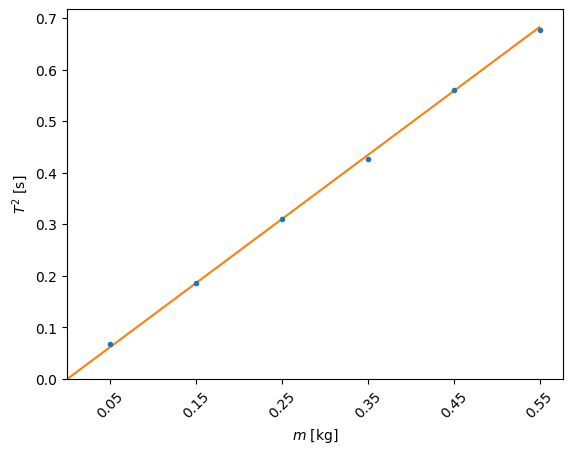

Il risultato del test del χ² è:
  χ²               = 129.40879
  Gradi di libertà = 5
  χ² ridotto       = 25.881757
  Il p-value associato è: 3.1771096e-26


In [ ]:
m1_1 = pd.to_numeric(df1.iloc[0:6, 7] - (0.0113)/3, errors='coerce').dropna().values

k1_1 = minquadw_kx(m1_1, unp.nominal_values(T_2), unp.std_devs(T_2))
t = np.linspace(0, max(m1_1))
plt.errorbar(m1_1, unp.nominal_values(T_2), yerr=unp.std_devs(T_2), fmt='o', ls='none', label='Dati', ms=3)
plt.plot(t, retta(t, k1_1.nominal_value))

plt.xlim(left=0)
plt.ylim(bottom=0)
plt.xticks(rotation=45)
plt.xticks(m1_1)
plt.xlabel(r'$m$ [kg]')
plt.ylabel(r'$T^2$ [s]')
plt.show()

print("="*70)
chi_quadro(unp.nominal_values(T_2), k1_1 * m1_1, unp.std_devs(T_2), 1)
print("="*70)

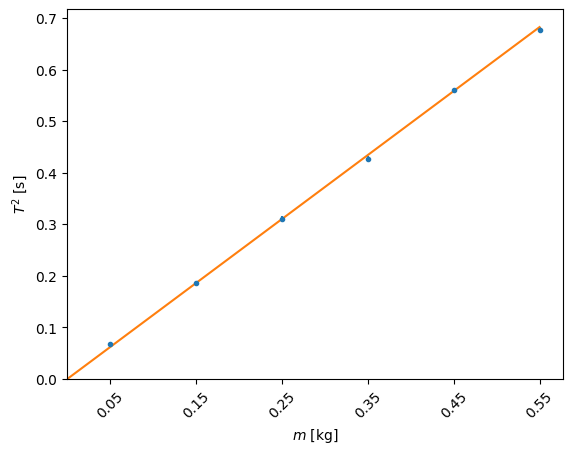

Il risultato del test del χ² è:
  χ²               = 5
  Gradi di libertà = 5
  χ² ridotto       = 1
  Il p-value associato è: 0.41588019
La misura dinamica di k è: 31.82±0.03
Test di compatibilità tra k_statico e k_dinamico: |t| = 1.1939176
Test di compatibilità tra k_d(sm) e k_d(m): |t| = 8.0856431


In [ ]:
sy_posteriori2= np.sqrt(np.sum((unp.nominal_values(T_2) - k1_1.nominal_value*m1_1)**2) / (len(T_2) - 1) )

plt.errorbar(m1_1, unp.nominal_values(T_2), yerr=sy_posteriori2, fmt='o', ls='none', label='Dati', ms=3)
plt.plot(t, retta(t, k1_1.nominal_value))
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.xticks(rotation=45)
plt.xticks(m1_1)
plt.xlabel(r'$m$ [kg]')
plt.ylabel(r'$T^2$ [s]')
plt.show()

print("="*70)
sy_array2 = np.full(len(T_2), sy_posteriori2)
chi_quadro(T_2, k1_1 * m1_1, sy_array2, 1)
print("="*70)
k_el1_1=(4*np.pi**2)/k1_1
print(f"La misura dinamica di k è: {k_el1_1:.4P}")
t_test(k_el0, k_el1_1, nome1="k_statico", nome2="k_dinamico");
t_test(k_el1, k_el1_1, nome1="k_d(sm)", nome2="k_d(m)");
print("="*70)

# Misura Statica (molla uguale)


In [ ]:
df2=pd.read_excel("Legge di Hooke.xlsx", sheet_name=2)
df2=df2.fillna('')
df2.round(5)

,m[kg],x [m],l [m],σl [m],x0 [m]
0,0.1,1.23,0.03,0.01414,1.26
1,0.2,1.19,0.07,0.01414,σx0 [m]
2,0.3,1.16,0.10,0.01414,0.01
3,0.4,1.13,0.13,0.01414,
4,0.5,1.10,0.16,0.01414,


Il risultato del fit y = k·x è:
  k = 0.32545455±0.01906925


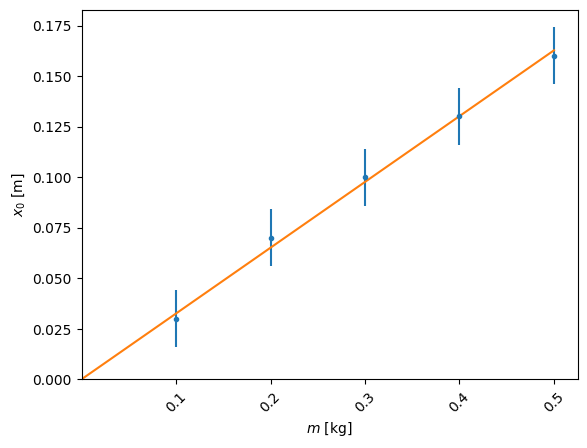

Il risultato del test del χ² è:
  χ²               = 0.21818182
  Gradi di libertà = 4
  χ² ridotto       = 0.054545455
  Il p-value associato è: 0.99446514
La misura statica di k è: 30.14±1.77


In [ ]:
allungamenti2 = df2.iloc[:, 2]
y2 = pd.to_numeric(allungamenti2, errors='coerce').dropna().values
sy2 = pd.to_numeric(df2.iloc[:, 3], errors='coerce').dropna().values
m2 = pd.to_numeric(df2.iloc[:, 0], errors='coerce').dropna().values

g=ufloat(9.81, 0.01)

k2 = minquadw_kx(m2, y2, sy2)

t = np.linspace(0, max(m2), 100)

plt.errorbar(m2, y2, yerr=sy2, fmt='o', ls='none', label='Dati', ms=3)
plt.plot(t, retta(t, k2.nominal_value))

plt.xlim(left=0)
plt.ylim(bottom=0)
plt.xticks(rotation=45)
plt.xticks(m2)
plt.xlabel(r'$m$ [kg]')
plt.ylabel(r'$x_0$ [m]')
plt.show()

print("="*70)
chi_quadro(y2, k2 * m2, sy2, 1)
print("="*70)
k_el2=g/k2
print(f"La misura statica di k è: {k_el2:.4P}")
print("="*70)

# Misura Statica (molla diversa)

In [ ]:
df3=pd.read_excel("Legge di Hooke.xlsx", sheet_name=3)
df3=df3.fillna('')
df3.round(5)

,m[kg],x [m],l [m],σl [m],x0 [m]
0,0.05,1.11,0.06,0.01414,1.17
1,0.07,1.09,0.08,0.01414,σx0 [m]
2,0.10,1.06,0.11,0.01414,0.01
3,0.15,1.01,0.16,0.01414,
4,0.20,0.95,0.22,0.01414,


Il risultato del fit y = k·x è:
  k = 1.0963705±0.0500313


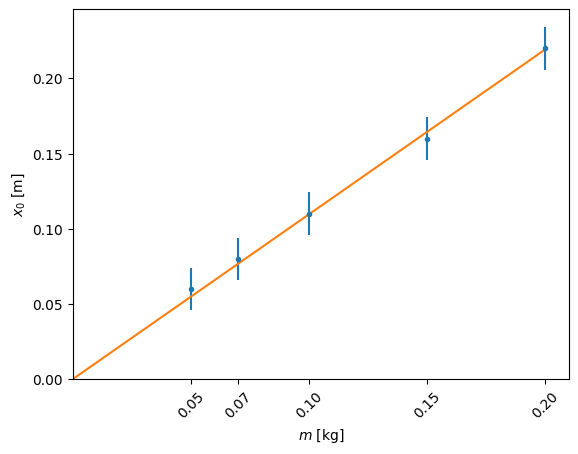

Il risultato del test del χ² è:
  χ²               = 0.28973717
  Gradi di libertà = 4
  χ² ridotto       = 0.072434293
  Il p-value associato è: 0.990467
La misura statica di k è: 8.948±0.408


In [ ]:
allungamenti3 = df3.iloc[:, 2]
y3 = pd.to_numeric(allungamenti3, errors='coerce').dropna().values
sy3 = pd.to_numeric(df3.iloc[:, 3], errors='coerce').dropna().values
m3 = pd.to_numeric(df3.iloc[:, 0], errors='coerce').dropna().values

k3 = minquadw_kx(m3, y3, sy3)

t = np.linspace(0, max(m3), 100)

plt.errorbar(m3, y3, yerr=sy3, fmt='o', ls='none', label='Dati', ms=3)
plt.plot(t, retta(t, k3.nominal_value))

plt.xlim(left=0)
plt.ylim(bottom=0)
plt.xticks(rotation=45)
plt.xticks(m3)
plt.xlabel(r'$m$ [kg]')
plt.ylabel(r'$x_0$ [m]')
plt.show()

print("="*70)
chi_quadro(y3, k3 * m3, sy3, 1)
print("="*70)
k_el3=g/k3
print(f"La misura statica di k è: {k_el3:.4P}")
print("="*70)

# Molle in Serie

In [ ]:
df4=pd.read_excel("Legge di Hooke.xlsx", sheet_name=4)
df4=df4.fillna('')
df4.round(5)

,m[kg],x [m],l [m],σl [m],x0 [m]
0,0.07,0.99,0.09,0.01414,1.08
1,0.10,0.94,0.14,0.01414,σx0 [m]
2,0.12,0.91,0.17,0.01414,0.01
3,0.15,0.87,0.21,0.01414,
4,0.20,0.80,0.28,0.01414,


Il risultato del fit y = k·x è:
  k = 1.3965142±0.0466760


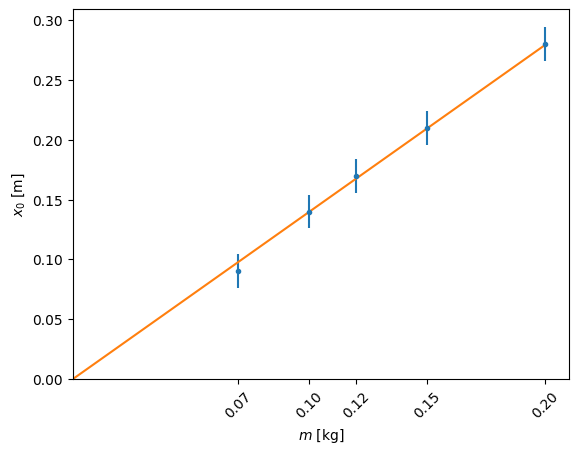

Il risultato del test del χ² è:
  χ²               = 0.33442266
  Gradi di libertà = 4
  χ² ridotto       = 0.083605664
  Il p-value associato è: 0.98748507
La misura di k equivalente è: 7.025±0.235
La misura di k teorico è: 6.936±0.249
Test di compatibilità tra k_exp e k_teo: |t| = 0.25877686


In [ ]:
allungamenti4 = df4.iloc[:, 2]
y4 = pd.to_numeric(allungamenti4, errors='coerce').dropna().values
sy4 = pd.to_numeric(df4.iloc[:, 3], errors='coerce').dropna().values
m4= pd.to_numeric(df4.iloc[:, 0], errors='coerce').dropna().values

k4 = minquadw_kx(m4, y4, sy4)

t = np.linspace(0, max(m4), 100)

plt.errorbar(m4, y4, yerr=sy4, fmt='o', ls='none', label='Dati', ms=3)
plt.plot(t, retta(t, k4.nominal_value))

plt.xlim(left=0)
plt.ylim(bottom=0)
plt.xticks(rotation=45)
plt.xticks(m4)
plt.xlabel(r'$m$ [kg]')
plt.ylabel(r'$x_0$ [m]')
plt.show()

print("="*70)
chi_quadro(y4, k4 * m4, sy4, 1)
print("="*70)
ks_exp=g/k4
ks_teo=(k_el3 * k_el0)/(k_el3 + k_el0)
print(f"La misura di k equivalente è: {ks_exp:.4P}")
print(f"La misura di k teorico è: {ks_teo:.4P}")
t_test(ks_exp, ks_teo, nome1="k_exp", nome2="k_teo");
print("="*70)

# Molle in Parallelo

In [ ]:
df5=pd.read_excel("Legge di Hooke.xlsx", sheet_name=5)
df5=df5.fillna('')
df5.round(5)

,m[kg],x [m],l [m],σl [m],x0 [m]
0,0.1,1.25,0.02,0.01414,1.27
1,0.2,1.23,0.04,0.01414,σx0 [m]
2,0.5,1.18,0.09,0.01414,0.01
3,0.7,1.15,0.12,0.01414,
4,0.9,1.12,0.15,0.01414,
5,1.0,1.10,0.17,0.01414,


Il risultato del fit y = k·x è:
  k = 0.17076923±0.00877058


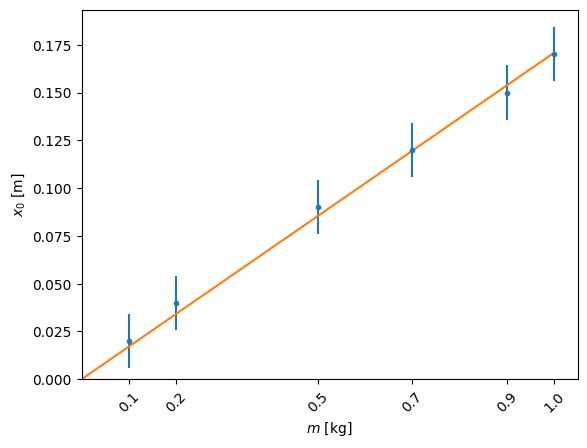

Il risultato del test del χ² è:
  χ²               = 0.39230769
  Gradi di libertà = 5
  χ² ridotto       = 0.078461538
  Il p-value associato è: 0.99553882
La misura di k equivalente è: 57.45±2.95
La misura di k teorico è: 60.99±1.94
Test di compatibilità tra k_exp e k_teo: |t| = 1.0043218


In [ ]:
allungamenti5 = df5.iloc[:, 2]
y5 = pd.to_numeric(allungamenti5, errors='coerce').dropna().values
sy5 = pd.to_numeric(df5.iloc[:, 3], errors='coerce').dropna().values
m5 = pd.to_numeric(df5.iloc[:, 0], errors='coerce').dropna().values


k5 = minquadw_kx(m5, y5, sy5)
t = np.linspace(0, max(m5), 100)

plt.errorbar(m5, y5, yerr=sy5, fmt='o', ls='none', label='Dati', ms=3)
plt.plot(t, retta(t, k5.nominal_value))

plt.xlim(left=0)
plt.ylim(bottom=0)
plt.xticks(rotation=45)
plt.xticks(m5)
plt.xlabel(r'$m$ [kg]')
plt.ylabel(r'$x_0$ [m]')
plt.show()

print("="*70)
chi_quadro(y5, k5 * m5, sy5, 1)
print("="*70)
kp_exp=g/k5
kp_teo=k_el2 + k_el0
print(f"La misura di k equivalente è: {kp_exp:.4P}")
print(f"La misura di k teorico è: {kp_teo:.4P}")
t_test(kp_exp, kp_teo, nome1="k_exp", nome2="k_teo");
print("="*70)

# Energia totale

In [ ]:
df6=pd.read_excel("Legge di Hooke.xlsx", sheet_name=6)
df6=df6.fillna('')
df6.round(5)

,t [s],x [m],v [m]
0,2.24,1.1223,0.00
1,2.26,1.1224,0.01
2,2.28,1.1227,0.02
3,2.30,1.1234,0.03
4,2.32,1.1241,0.04
5,2.34,1.1249,0.05
6,2.36,1.1259,0.06
7,2.38,1.1273,0.06
8,2.40,1.1284,0.07
9,2.42,1.1300,0.07


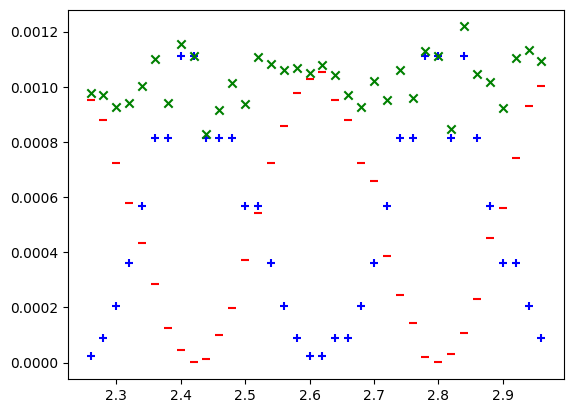

In [ ]:
tempi2 = df6.iloc[1:37, 0]

t = pd.to_numeric(tempi2, errors='coerce').dropna().values

posizione = df6.iloc[1:37, 1]
velocità = df6.iloc[1:37, 2]
v=pd.to_numeric(velocità, errors='coerce').dropna().values
x = pd.to_numeric(posizione, errors='coerce').dropna().values

em=0.453*(v**2)/2
ep=k_el1.nominal_value*((x-1.1301)**2)/2
etot=em+ep
plt.scatter(t, ep, color='red', marker='_')
plt.scatter(t, em, color='blue', marker='+')
plt.scatter(t, etot, color='green', marker='x')


plt.show()

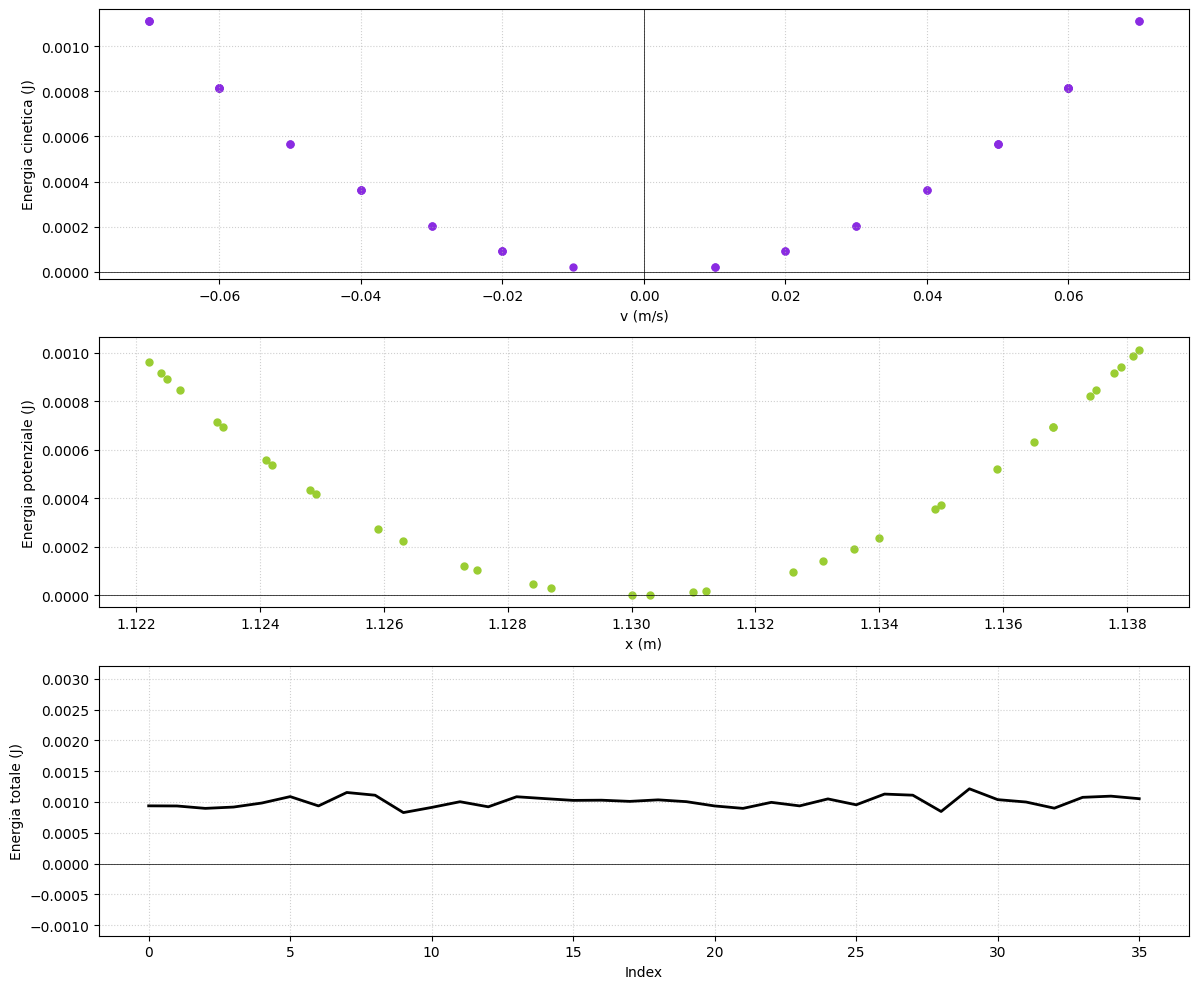

In [ ]:
# Indice per l'asse X dell'ultimo grafico
indice = np.arange(len(t))

E_cinetica = 0.5 * 0.453 * (v**2)
E_potenziale = 0.5 * 30.852288 * ((x - 1.1301)**2)
Etot = E_cinetica + E_potenziale

fig, axs = plt.subplots(3, 1, figsize=(12, 10))

# Grafico 1: Calc2 vs v (Viola)
axs[0].scatter(v, E_cinetica, color='blueviolet', s=25)
axs[0].set_xlabel('v (m/s)')
axs[0].set_ylabel('Energia cinetica (J)')
axs[0].axhline(0, color='black', linewidth=0.5)
axs[0].axvline(0, color='black', linewidth=0.5)
axs[0].grid(True, linestyle=':', alpha=0.6)

# Grafico 2: Calc4 vs x (Verde)
axs[1].scatter(x, E_potenziale, color='yellowgreen', s=25)
axs[1].set_xlabel('x (m)')
axs[1].set_ylabel('Energia potenziale (J)')
axs[1].axhline(0, color='black', linewidth=0.5)
axs[1].grid(True, linestyle=':', alpha=0.6)

# Grafico 4: Etot vs Indice (Nero/Scuro)
axs[2].plot(indice, Etot, color='black', linewidth=2, label='Etot')
axs[2].set_xlabel('Index')
axs[2].set_ylabel('Energia totale (J)')
axs[2].axhline(0, color='black', linewidth=0.5)

axs[2].set_ylim(min(Etot) - 0.002, max(Etot) + 0.002)
axs[2].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

Risultati del Fit:
Massa efficace fittata: 0.4530 kg (Valore teorico impostato: 0.453)
Costante elastica fittata: 30.8523 N/m (Valore teorico impostato: 30.852)
Posizione di equilibrio fittata: 1.1301 m (Valore teorico impostato: 1.1301)



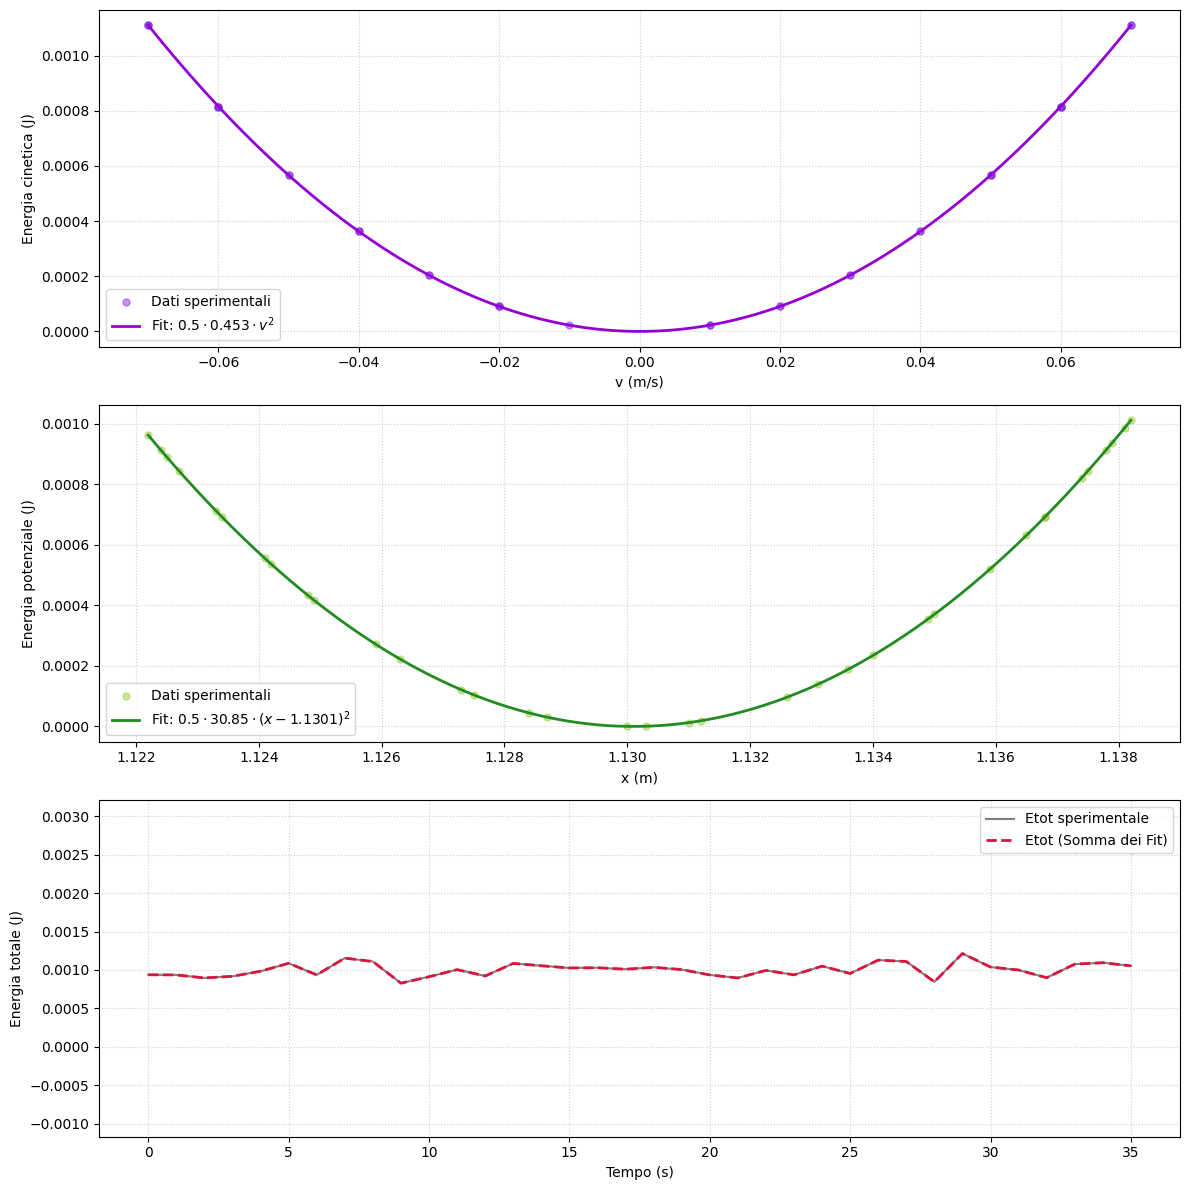

In [ ]:
def modello_cinetica(v, m_effettiva):
    # E_cin = 0.5 * m * v^2
    return 0.5 * m_effettiva * (v**2)

def modello_potenziale(x, k_effettiva, x0):
    # E_pot = 0.5 * k * (x - x0)^2
    return 0.5 * k_effettiva * ((x - x0)**2)

popt_cin, _ = curve_fit(modello_cinetica, v, E_cinetica, p0=[0.453])
popt_pot, _ = curve_fit(modello_potenziale, x, E_potenziale, p0=[30.852, 1.1301])

# Estrazione parametri
m_fit = popt_cin[0]
k_fit = popt_pot[0]
x0_fit = popt_pot[1]

print(f"Risultati del Fit:")
print(f"Massa efficace fittata: {m_fit:.4f} kg (Valore teorico impostato: 0.453)")
print(f"Costante elastica fittata: {k_fit:.4f} N/m (Valore teorico impostato: 30.852)")
print(f"Posizione di equilibrio fittata: {x0_fit:.4f} m (Valore teorico impostato: 1.1301)\n")

v_line = np.linspace(min(v), max(v), 500)
x_line = np.linspace(min(x), max(x), 500)

E_cin_fit = modello_cinetica(v_line, m_fit)
E_pot_fit = modello_potenziale(x_line, k_fit, x0_fit)

Etot_fit = modello_cinetica(v, m_fit) + modello_potenziale(x, k_fit, x0_fit)

#GRAFICI
fig, axs = plt.subplots(3, 1, figsize=(12, 12))

# Grafico 1: Cinetica + Fit
axs[0].scatter(v, E_cinetica, color='blueviolet', s=25, alpha=0.5, label='Dati sperimentali')
axs[0].plot(v_line, E_cin_fit, color='darkviolet', linewidth=2, label=f'Fit: $0.5 \\cdot {m_fit:.3f} \\cdot v^2$')
axs[0].set_xlabel('v (m/s)')
axs[0].set_ylabel('Energia cinetica (J)')
axs[0].grid(True, linestyle=':', alpha=0.6)
axs[0].legend()

# Grafico 2: Potenziale + Fit
axs[1].scatter(x, E_potenziale, color='yellowgreen', s=25, alpha=0.5, label='Dati sperimentali')
axs[1].plot(x_line, E_pot_fit, color='forestgreen', linewidth=2, label=f'Fit: $0.5 \\cdot {k_fit:.2f} \\cdot (x - {x0_fit:.4f})^2$')
axs[1].set_xlabel('x (m)')
axs[1].set_ylabel('Energia potenziale (J)')
axs[1].grid(True, linestyle=':', alpha=0.6)
axs[1].legend()

# Grafico 3: Energia Totale (Dati vs Somma dei Fit)
axs[2].plot(indice, Etot, color='black', linewidth=1.5, alpha=0.5, label='Etot sperimentale')
axs[2].plot(indice, Etot_fit, color='crimson', linewidth=2, linestyle='--', label='Etot (Somma dei Fit)')
axs[2].set_xlabel('Tempo (s)')
axs[2].set_ylabel('Energia totale (J)')
axs[2].set_ylim(min(min(Etot), min(Etot_fit)) - 0.002, max(max(Etot), max(Etot_fit)) + 0.002)
axs[2].grid(True, linestyle=':', alpha=0.6)
axs[2].legend()

plt.tight_layout()
plt.show()
plt.show()